In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
# from tqdm import tqdm
# import gc
# import time
import json
from pprint import pprint
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import talib

# from pklib.strategy import *
from pklib.utilities import *
# from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *

# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import precision_score, recall_score

# import seaborn as sns
# from pklib.rl import *

### IMPORTANT
# pip install numpy==1.26.4 pandas==2.2.1 --force-reinstall

In [3]:
import dotenv
import os

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv(".env", override=True)

# 'MY_VAR' is refreshed now
print('HIP_VISIBLE_DEVICES = ', os.environ.get('HIP_VISIBLE_DEVICES')) # MY_VAR = HELLO_BOB

HIP_VISIBLE_DEVICES =  0


In [4]:
import torch
import torch as T
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [156]:
import pandas as pd

def add_lagged(df, feature_list, lag_periods):
    df_lagged = df#.copy()
    
    # For each feature, create lagged features
    for feature in feature_list:
        for lag in lag_periods:
            lagged_feature_name = f'{feature}_{lag}'.replace('-', '__')
            df_lagged[lagged_feature_name] = df[feature].shift(lag)
    
    return df_lagged


In [225]:

exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; timeframe='8h'; 
test_size= 0.5; resample = None;
lookback_period, target_period, min_target_pct, risk_2_reward = 3, 3, 0.01, 2
window_size = 7 ; 
###########################
df = load_candles(exchange, asset, quote, timeframe).ffill().bfill()
# df['volume'] = df.volume.replace(0, np.nan).ffill()
df.drop('volume', axis=1, inplace=True)
df = df.apply(np.log)
df['ret'] = df.close - df.open

df['bu'] = df[['open', 'close']].max(axis=1)
df['bd'] = df[['open', 'close']].min(axis=1)
df['wur'] = df.high - df.bu
df['wdr'] = df.bd - df.low


df = add_lagged(df, ['open', 'high', 'low', 'close', 'ret', 'bu', 'bd', 'wur', 'wdr'], np.arange(6)).dropna()
df = add_lagged(df, ['open', 'high', 'low', 'close', 'ret', 'bu', 'bd', 'wur', 'wdr'], -np.arange(6)).dropna()
df


,open,high,low,close,ret,bu,bd,wur,wdr,open_0,...,wur___1,wur___2,wur___3,wur___4,wur___5,wdr___1,wdr___2,wdr___3,wdr___4,wdr___5
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-08-18 16:00:00,8.351030,8.365847,8.278624,8.320782,-0.030248,8.351030,8.320782,0.014817,0.042158,8.351030,...,0.018406,0.016360,0.002415,0.000166,0.013197,0.025171,0.031209,0.020725,0.018857,0.022650
2017-08-19 00:00:00,8.320782,8.339188,8.277211,8.302382,-0.018399,8.320782,8.302382,0.018406,0.025171,8.320782,...,0.016360,0.002415,0.000166,0.013197,0.014665,0.031209,0.020725,0.018857,0.022650,0.004208
2017-08-19 08:00:00,8.302382,8.318742,8.255828,8.287038,-0.015345,8.302382,8.287038,0.016360,0.031209,8.302382,...,0.002415,0.000166,0.013197,0.014665,0.012332,0.020725,0.018857,0.022650,0.004208,0.022567
2017-08-19 16:00:00,8.303056,8.330861,8.282331,8.328446,0.025390,8.328446,8.303056,0.002415,0.020725,8.303056,...,0.000166,0.013197,0.014665,0.012332,0.010942,0.018857,0.022650,0.004208,0.022567,0.027784
2017-08-20 00:00:00,8.323846,8.332443,8.304990,8.332277,0.008431,8.332277,8.323846,0.000166,0.018857,8.323846,...,0.013197,0.014665,0.012332,0.010942,0.013477,0.022650,0.004208,0.022567,0.027784,0.022005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:00:00,11.017388,11.018219,10.979854,10.982331,-0.035057,11.017388,10.982331,0.000831,0.002477,11.017388,...,0.011941,0.000461,0.008172,0.010814,0.001192,0.004725,0.003911,0.011183,0.002301,0.020868
2024-08-20 16:00:00,10.982331,10.997468,10.977606,10.985527,0.003195,10.985527,10.982331,0.011941,0.004725,10.982331,...,0.000461,0.008172,0.010814,0.001192,0.006793,0.003911,0.011183,0.002301,0.020868,0.005102
2024-08-21 00:00:00,10.985527,10.997749,10.981616,10.997288,0.011762,10.997288,10.985527,0.000461,0.003911,10.985527,...,0.008172,0.010814,0.001192,0.006793,0.004962,0.011183,0.002301,0.020868,0.005102,0.004064


<Axes: xlabel='timestamp'>

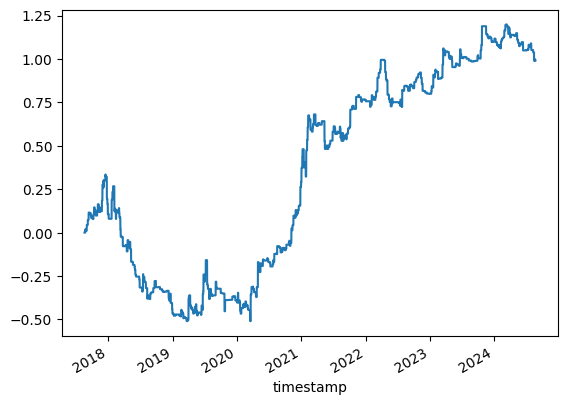

In [226]:
cond = (
        1
        & (df.ret > 0)
        & (df.ret_1 > 0)
        & (df.ret_2 > 0)
        & (df.ret_3 < 0)
        # & (df.close_4 > df.open_4)
        # & ((df.close - df.open) > (df.close_1 - df.open_1))
        # & ((df.close_1 - df.open_1) > (df.close_2 - df.open_2))
        # & ((df.close_2 - df.open_2) > (df.close_3 - df.open_3))
        # & (df.close > df.low_1)
        # & (df.close_1 > df.low_2)
        # & (df.close_2 > df.low_3)
        # & ((df.close_1 - df.open_1) < (df.close_2 - df.open_2))
        # & (df.close_2 >= df.low_2)
        # & (df.close_3 >= df.low_2)
    )
(cond * (df.close.shift(-3).ffill() - df.close)).cumsum().plot()

In [236]:
(df.low___1 - df.bd)[cond].describe()

count    484.000000
mean      -0.000403
std        0.019225
min       -0.108376
25%       -0.008560
50%       -0.000691
75%        0.008285
max        0.079557
dtype: float64

In [237]:
#  & (df.high___1 > df.bu)
# ((df.low___1 > df.low) & (df.low___1 <= df.bd))[cond].value_counts()
(df.low___1 > df.low*0.999)[(cond & (df.low___1 <= df.bd))] .value_counts()

True     193
False     62
Name: count, dtype: int64

In [243]:

(df.high___1 > df.bu)[(cond & (df.low___1 <= df.bd) & (df.low___1 > df.low*0.999))] .value_counts()

True     191
False      2
Name: count, dtype: int64

In [242]:
(df.high___1 - df.close)[(cond & (df.low___1 <= df.bd) & (df.low___1 > df.low*0.999))] .describe()

count    255.000000
mean       0.011417
std        0.015053
min       -0.000186
25%        0.002699
50%        0.006688
75%        0.013150
max        0.099926
dtype: float64

<Axes: xlabel='timestamp'>

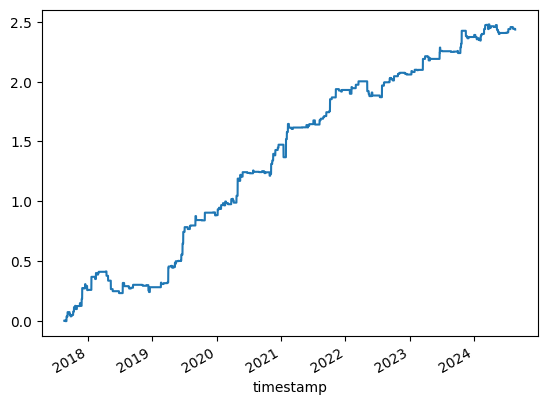

In [228]:
((cond & (df.low___1 >= df.bd)) * (df[['ret___1','ret___2','ret___3']].sum(axis=1))).cumsum().plot()

<Axes: xlabel='timestamp'>

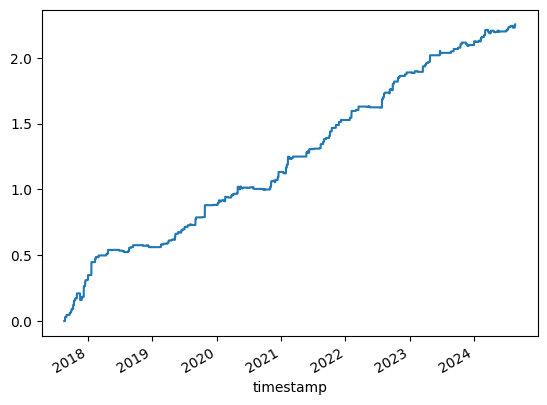

In [234]:
((cond & (df.low___1 >= df.bd)) * (df[['ret___1']].sum(axis=1))).cumsum().plot()

In [137]:
(cond * (df.close.shift(-4).ffill() - df.close)).describe()

count    15358.000000
mean         0.000314
std          0.009738
min         -0.129776
25%          0.000000
50%          0.000000
75%         -0.000000
max          0.231307
dtype: float64

<Axes: xlabel='timestamp'>

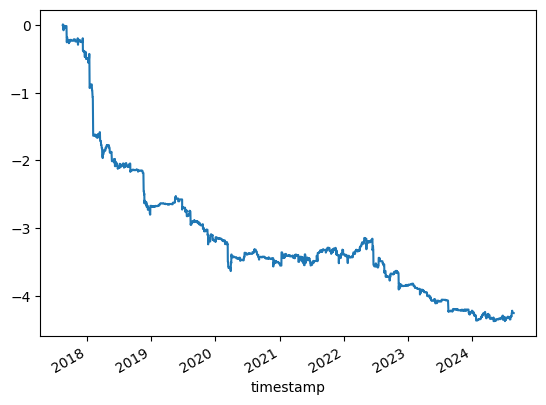

In [111]:
cond = (
        1
        # & (df.close > df.open)
        & (df.close_1 < df.open_1)
        & (df.close_2 < df.open_2)
        & (df.close_3 < df.open_3)
        # & (df.close_4 < df.open_4)
        # & ((df.close - df.open) > (df.close_1 - df.open_1))
        # & ((df.close_1 - df.open_1) > (df.close_2 - df.open_2))
        # & ((df.close_2 - df.open_2) > (df.close_3 - df.open_3))
        # & (df.close > df.low_1)
        # & (df.close_1 > df.low_2)
        # & (df.close_2 > df.low_3)
        # & ((df.close_1 - df.open_1) < (df.close_2 - df.open_2))
        # & (df.close_2 >= df.low_2)
        # & (df.close_3 >= df.low_2)
    )
(cond * (df.close.shift(-2).ffill() - df.close)).cumsum().plot()

In [112]:
((cond) * ((df.close > df.open).shift(-1) * 2 - 1) ).value_counts()

0     13990
1       695
-1      676
Name: count, dtype: int64